# Interactive region annotation

This tutorial shows how to use `.pl.annotate()` to draw regions of interest directly on top of a `spatialdata-plot` rendering and persist them as a `ShapesModel` element. The widget is built on [`anybioimage`]'s `BioImageViewer`, which renders the image once and handles all drawing client-side — so it works over SSH (Jupyter or VSCode-Remote-SSH) without streaming PNG frames per mouse-move.

**Dataset**: a Visium H&E mouse brain section, downloaded by `squidpy.datasets.visium_hne_sdata`.

**Requires the `interactive` extra:**

```bash
pip install 'spatialdata-plot[interactive]'
```

[`anybioimage`]: https://github.com/maartenpaul/anybioimage

## Loading the dataset

We'll use the `squidpy.datasets.visium_hne_sdata()` test data to demonstrate the function. The `SpatialData` object contains a multi-resolution H&E image (`'hne'`) and the spot polygons (`'spots'`), both aligned in the `'global'` coordinate system.

In [1]:
import squidpy as sq
from shapely.geometry import Polygon

import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the .pl accessor)
from spatialdata.models import ShapesModel
from spatialdata.transformations.transformations import Identity

sdata = sq.datasets.visium_hne_sdata()
sdata

INFO     Loading existing dataset from data/spatialdata/visium_hne_sdata.zarr                                      


/Users/tim.treis/Documents/GitHub/spatialdata-plot-notebooks/.pixi/envs/default/lib/python3.14/site-packages/squidpy/datasets/_downloader.py:209: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  return sd.read_zarr(zarr_path)
/Users/tim.treis/Documents/GitHub/spatialdata-plot-notebooks/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot-notebooks/examples/data/spatialdata/visium_hne_sdata.zarr
├── Images
│     └── 'hne': DataTree[cyx] (3, 11757, 11291), (3, 5878, 5645), (3, 2939, 2822), (3, 1469, 1411)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (2688, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (2688, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), spots (Shapes)

## Inspect what we'll annotate

Before drawing, let's render the image so we know what to outline.

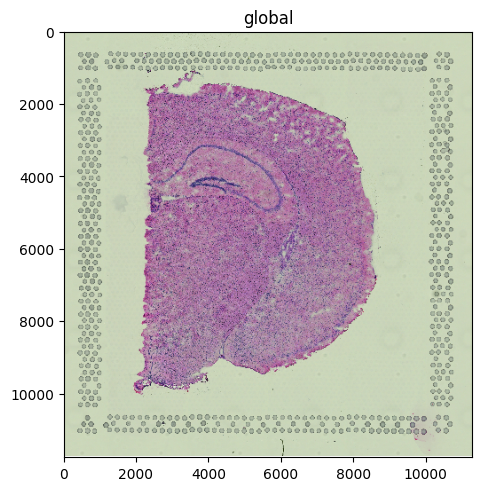

In [3]:
sdata.pl.render_images("hne").pl.show()

## Launching the widget

`annotate()` is a terminal step on a render chain: it rasterises whatever you composed upstream (`render_images` / `render_shapes` / `render_points` / `render_labels`) and hands the resulting RGB to the `BioImageViewer`. Drawn shapes are mapped back from canvas pixels into the chosen coordinate system and stored in `sdata.shapes[<name>]` with an `Identity` transformation in that CS.

```python
(
    sdata
    .pl.render_images("hne")
    .pl.annotate(coordinate_systems="global")
)
```

> The code above is intentionally a Markdown block, not a code cell — the widget needs a live JS runtime, which the static docs build can't provide. Run the line in your own notebook (Jupyter Lab or VSCode-Remote-SSH) to see the canvas.

**Drawing tools**: rectangle, polygon, point. Points are stored as small circle polygons (radius scaled to the rendered image's CS extent) so the resulting `ShapesModel` is uniform-type.

When you click **Save** the shapes on the canvas are committed to `sdata.shapes[<name>]` as a single `ShapesModel` (multiple rows if you drew multiple shapes). Same-name commits overwrite. Use `sdata.write_element(<name>)` after the cell to persist to a backing zarr.

![Drawing a region with sdata.pl.annotate](../_static/img/interactive_annotate.gif)

*Live recording of the widget.*

## What the widget produces

To keep the rest of this notebook reproducible without a live kernel, the next cell manually creates a similar `ShapesModel` the widget would have written if you'd drawn a polygon around the hippocampus and clicked Save with the name `'tumor_region'`. After this cell, downstream code is identical regardless of whether you ran the widget or this simulated commit.

In [18]:
# Pretend the user drew this polygon in the widget and clicked Save with
# name="poly". Coordinates are in the 'global' coordinate system
# of the visium_hne_sdata dataset.
hippocampus_polygon = Polygon(
    [
        (2540, 3946),
        (3105, 3597),
        (3387, 3149),
        (3750, 2953),
        (4449, 2939),
        (5054, 3065),
        (5511, 3317),
        (6008, 3835),
        (6223, 4198),
        (6398, 4688),
        (6344, 5052),
        (6115, 5346),
        (5712, 5304),
        (5242, 4926),
        (4919, 4688),
        (4449, 4534),
        (3777, 4548),
        (3333, 4548),
        (2876, 4520),
        (2540, 4478),
        (2540, 3946)
    ]
)

import geopandas as gpd

sdata.shapes["poly"] = ShapesModel.parse(
    gpd.GeoDataFrame({"geometry": [hippocampus_polygon]}),
    transformations={"global": Identity()},
)
sdata.shapes["poly"]

,geometry
0,"POLYGON ((2540 3946, 3105 3597, 3387 3149, 375..."


## Working with the saved region

The committed element is a normal `ShapesModel` — every downstream API in `spatialdata` and `spatialdata-plot` treats it like any other shapes layer. Here we overlay it on the H&E to confirm placement.

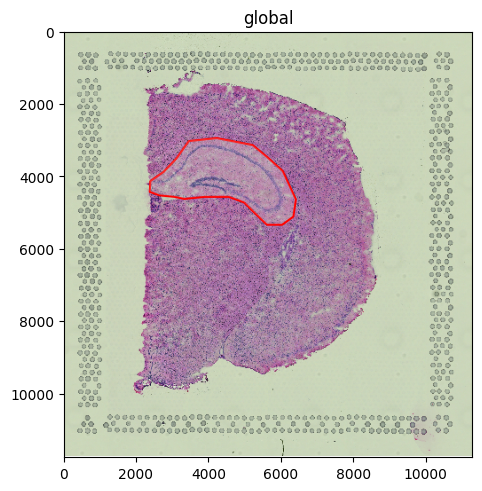

In [3]:
(
    sdata
    .pl.render_images("hne")
    .pl.render_shapes("poly", outline_color="red", fill_alpha=0.2)
    .pl.show()
)

## Cropping the dataset to the region

Because the region is a registered `ShapesModel`, `sdata.query.polygon` can subset every element down to what falls inside it. Useful for focused analyses or quick QC on a single anatomical structure.

In [4]:
subset = sd.polygon_query(
    sdata,
    sdata["poly"].geometry.iloc[0],
    target_coordinate_system="global",
)
subset

SpatialData object
├── Images
│     └── 'hne': DataTree[cyx] (3, 2394, 4035), (3, 1196, 2017), (3, 599, 1008), (3, 299, 504)
├── Shapes
│     ├── 'poly': GeoDataFrame shape: (1, 1) (2D shapes)
│     └── 'spots': GeoDataFrame shape: (362, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (362, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), poly (Shapes), spots (Shapes)

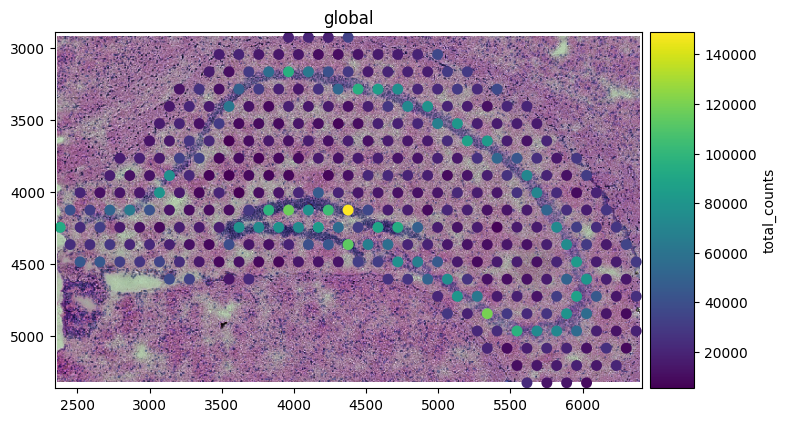

In [5]:
(
    subset
    .pl.render_images("hne")
    .pl.render_shapes("spots", color="total_counts")
    .pl.show()
)

## For reproducibility

In [31]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import anywidget

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,anywidget,squidpy,matplotlib,numpy

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.3.5.dev26+g694ed9238
anywidget       : 0.11.0
squidpy         : 1.8.1
matplotlib      : 3.10.9
numpy           : 2.4.4

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

